In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("ML-EdgeIIoT-dataset.csv", low_memory=False)
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6,192.168.0.152,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,MITM
1,6,192.168.0.101,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,MITM
2,6,192.168.0.152,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,MITM
3,6,192.168.0.101,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,MITM
4,6,192.168.0.152,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,MITM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157795,2021 23:24:32.698981000,193.152.82.43,192.168.0.128,0,0,0,0,48729,40690,0,...,0,0,0,0,0,0,0,0,1,DDoS_ICMP
157796,2021 23:24:32.699354000,253.52.1.213,192.168.0.128,0,0,0,0,45657,40702,0,...,0,0,0,0,0,0,0,0,1,DDoS_ICMP
157797,2021 23:24:32.719931000,107.155.221.49,192.168.0.128,0,0,0,0,57686,41423,0,...,0,0,0,0,0,0,0,0,1,DDoS_ICMP
157798,2021 23:24:32.752054000,77.242.58.228,192.168.0.128,0,0,0,0,9555,42379,0,...,0,0,0,0,0,0,0,0,1,DDoS_ICMP


In [3]:
#encode data labels of attack types
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Attack_type'] = label_encoder.fit_transform(df['Attack_type'])
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

{'Backdoor': np.int64(0), 'DDoS_HTTP': np.int64(1), 'DDoS_ICMP': np.int64(2), 'DDoS_TCP': np.int64(3), 'DDoS_UDP': np.int64(4), 'Fingerprinting': np.int64(5), 'MITM': np.int64(6), 'Normal': np.int64(7), 'Password': np.int64(8), 'Port_Scanning': np.int64(9), 'Ransomware': np.int64(10), 'SQL_injection': np.int64(11), 'Uploading': np.int64(12), 'Vulnerability_scanner': np.int64(13), 'XSS': np.int64(14)}


In [4]:
non_numeric_cols = df.select_dtypes(include=['object']).columns
print(non_numeric_cols)

Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport',
       'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname',
       'mqtt.topic'],
      dtype='object')


In [5]:
df.drop(columns=non_numeric_cols, inplace=True, errors='ignore')

In [6]:
df = df.drop(["icmp.unused","http.tls_port","mqtt.msg_decoded_as"],axis=1)

In [7]:
X = df.drop(['Attack_label','Attack_type'], axis=1)
y = df['Attack_type']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42,n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = rf.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9174588086185045

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      2039
           1       0.81      0.79      0.80      2112
           2       1.00      1.00      1.00      2818
           3       1.00      1.00      1.00      2050
           4       1.00      1.00      1.00      2900
           5       0.55      0.80      0.65       200
           6       0.40      1.00      0.57       243
           7       0.98      0.99      0.98      4860
           8       0.80      0.78      0.79      1998
           9       0.96      0.93      0.94      2014
          10       0.97      0.87      0.92      2185
          11       0.78      0.84      0.81      2062
          12       0.89      0.86      0.87      2054
          13       0.99      0.95      0.97      2015
          14       0.83      0.80      0.81      2010

    accuracy                           0.92     31560
   macro avg       0.86   

In [11]:
importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Keep only important features (threshold = 0.01)
important_features = feature_importance[feature_importance['importance'] > 0.01]['feature']

print("Selected Features:", len(important_features))

Selected Features: 13


In [12]:
X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

In [13]:
rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=40,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_final.fit(X_train_selected, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,40
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_final.predict(X_test_selected)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Accuracy: 0.9201520912547528

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      2039
           1       0.76      0.89      0.82      2112
           2       1.00      1.00      1.00      2818
           3       1.00      1.00      1.00      2050
           4       1.00      1.00      1.00      2900
           5       1.00      0.77      0.87       200
           6       0.26      1.00      0.42       243
           7       0.99      0.99      0.99      4860
           8       0.84      0.78      0.81      1998
           9       1.00      0.89      0.94      2014
          10       0.96      0.87      0.91      2185
          11       0.82      0.84      0.83      2062
          12       0.93      0.85      0.89      2054
          13       1.00      0.95      0.97      2015
          14       0.87      0.80      0.84      2010

    accuracy                           0.92     31560
   macro avg       0

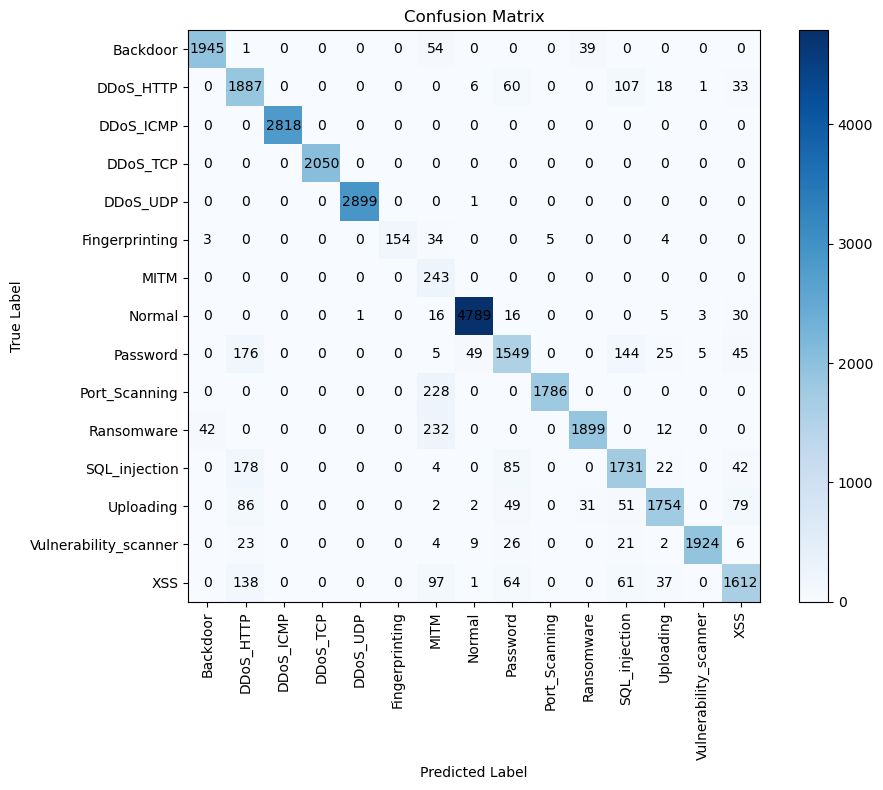

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(
    cm,
    interpolation='nearest',
    cmap=plt.cm.Blues,   # Blue color map
    vmin=0,              # Force 0 to be white
    vmax=cm.max()        # Max value = darkest blue
)

plt.title("Confusion Matrix")
plt.colorbar()

class_names = label_encoder.classes_
tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()


In [16]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Mean CV accuracy:", scores.mean())

Mean CV accuracy: 0.8706147021546261


In [17]:
from sklearn.preprocessing import label_binarize

if len(y_test.shape) == 1:
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
else:
    y_test_bin = y_test

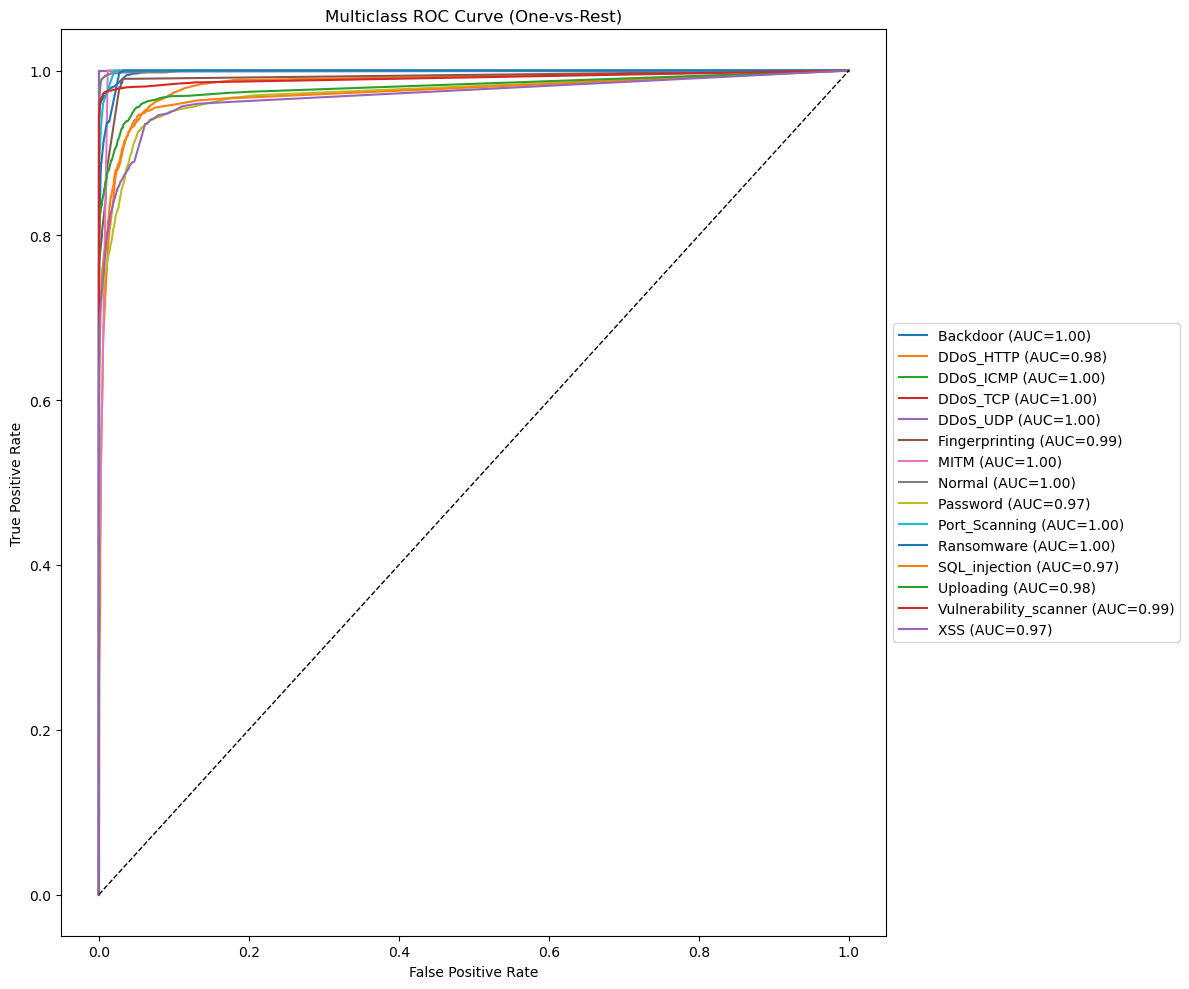

In [19]:
y_score = rf.predict_proba(X_test)
from sklearn.metrics import roc_curve, auc
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12,10))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.5,
             label=f'{class_names[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))  # legend outside
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
print("Macro AUC:", macro_auc)

Macro AUC: 0.9902926681713468


In [21]:
# Get class names
class_names = label_encoder.classes_

# Compute AUC per class
auc_scores = []

for i in range(len(class_names)):
    auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    auc_scores.append(auc)

# Create table
auc_table = pd.DataFrame({
    "Class": class_names,
    "AUC": auc_scores
})

print(auc_table)

                    Class       AUC
0                Backdoor  0.998621
1               DDoS_HTTP  0.982871
2               DDoS_ICMP  1.000000
3                DDoS_TCP  1.000000
4                DDoS_UDP  1.000000
5          Fingerprinting  0.991847
6                    MITM  0.996315
7                  Normal  0.999631
8                Password  0.972136
9           Port_Scanning  0.999265
10             Ransomware  0.998172
11          SQL_injection  0.974165
12              Uploading  0.980276
13  Vulnerability_scanner  0.991180
14                    XSS  0.969912
